In [3]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [4]:
iris=load_iris()

In [5]:
X=pd.DataFrame(iris.data)
X.columns=iris.feature_names
y=iris.target

In [6]:
X.shape

(150, 4)

In [7]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
X=iris.data
y=iris.target

<Axes: >

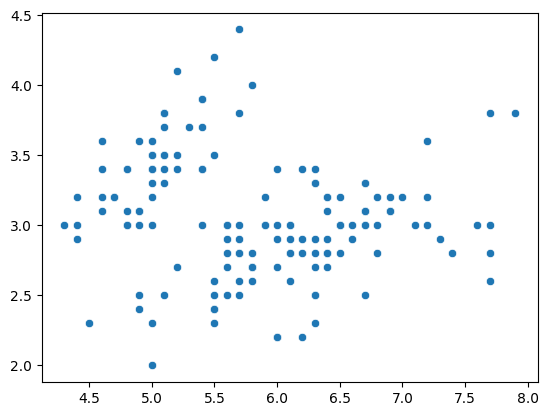

In [9]:
sns.scatterplot(x=X[:,0],y=X[:,1])

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [14]:
#elbow method
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

<Axes: >

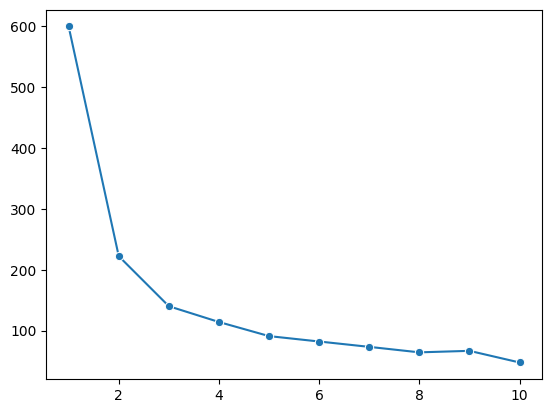

In [15]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

In [19]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

<Axes: >

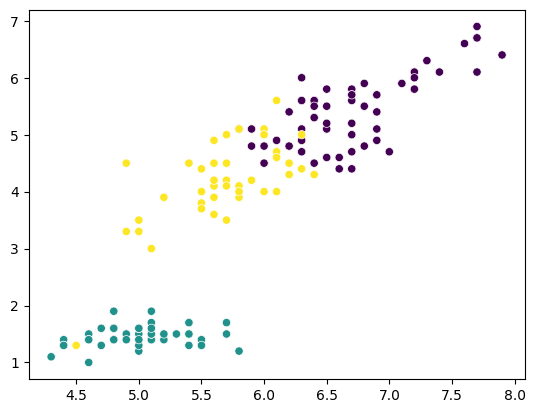

In [18]:
kmeans=KMeans(n_clusters=3)
labels=kmeans.fit_predict(X_scaled)
sns.scatterplot(x=X[:,0],y=X[:,2],c=labels)

<Axes: >

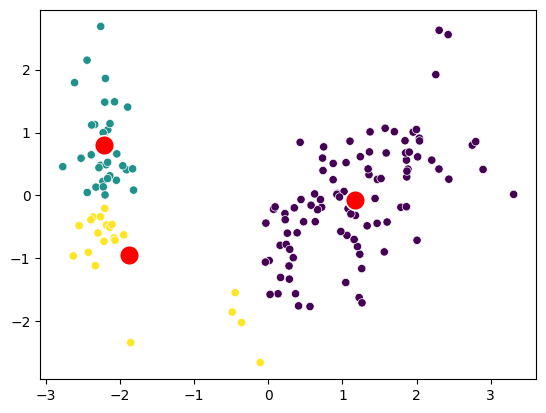

In [24]:
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="o",c="red",s=200)